# Particle tracing

In this tutorial you will build and compare particle-tracing simulations with the toy models [Vlasov](https://struphy.pages.mpcdf.de/struphy/sections/subsections/models_toy.html#struphy.models.toy.Vlasov) and [GuidingCenter](https://struphy.pages.mpcdf.de/struphy/sections/subsections/models_toy.html#struphy.models.toy.GuidingCenter).

By the end, you will know how to:

1. change the geometry,
2. choose different particle loading strategies,
3. add a static background magnetic field.

## Part 1: Particles in a cylinder

As in Tutorial 2, we recreate the setup directly in the notebook so each option is visible and easy to modify. If you prefer starting from default launch files in a terminal, run:

```
struphy params Vlasov
struphy params GuidingCenter
```

Here we set the simulation domain $\Omega$ to a cylinder and compare two sampling strategies for particle positions:

- uniform in logical space $[0,1]^3 = F^{-1}(\Omega)$,
- uniform directly in the physical cylinder $\Omega$.

Start by importing the API and the model:

In [1]:
from struphy import BaseUnits, EnvironmentOptions, Time
from struphy import equils
from struphy import domains
from struphy import grids
from struphy import DerhamOptions
from struphy import maxwellians
from struphy import (BoundaryParameters, 
                     LoadingParameters, 
                     WeightsParameters,
                     SortingParameters,
                     SavingParameters,
                     )
from struphy import Simulation

# import model
from struphy.models import Vlasov

### Step 1: define separate output folders

We will run two comparable simulations and save them in different output folders. Set the folder names through environment variables:

In [2]:
# light-weight model instances
model = Vlasov()
model_2 = Vlasov()

# environment options
env = EnvironmentOptions()
env_2 = EnvironmentOptions(sim_folder="sim_2")

### Step 2: set shared simulation options

Keep the generic options identical in both runs so the loading strategy is the main difference. We perform only one time step, use a cylindrical geometry, and leave the equilibrium empty:

In [3]:
# time stepping
time_opts = Time(dt=0.2, Tend=0.2)

# geometry
a1 = 1e-6 # to avoid polar singularity, we cut a small hole around the axis.
a2 = 5.0
Lz = 20.0
domain = domains.HollowCylinder(a1=a1, a2=a2, Lz=Lz)

# fluid equilibrium (can be used as part of initial conditions)
equil = None

# grid
grid = grids.TensorProductGrid()

# derham options
derham_opts = DerhamOptions()

### Step 3: instantiate the first simulation

Create the first simulation object with the baseline particle loading:

In [4]:
sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

Struphy provides a convenient way to clone a simulation and change only selected parameters.

Use that pattern here to create a second simulation with modified model/environment options:

In [5]:
sim_2 = sim.spawn_sister(model= model_2, env=env_2)

### Step 4: inspect the domain

Before changing the loading options, verify the simulation domain visually:

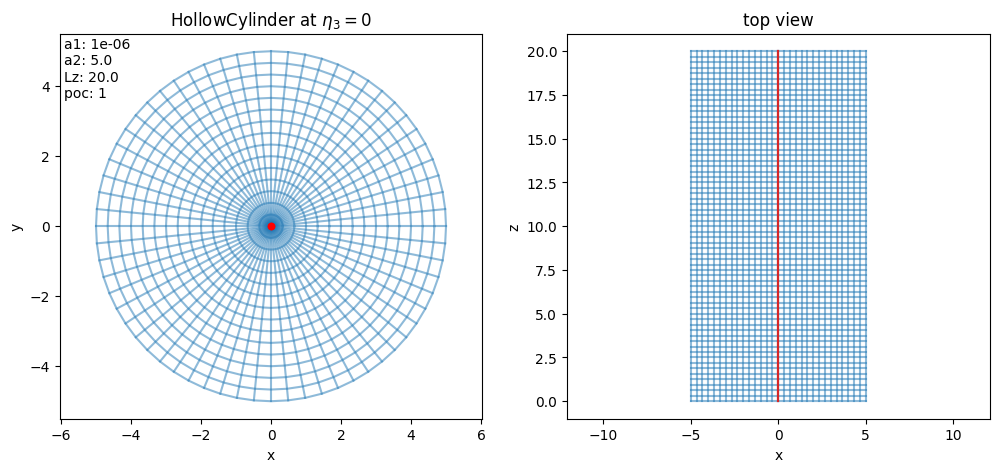

In [6]:
domain.show()

For the second simulation, set `spatial="disc"` in the loading parameters.

This samples particles uniformly on the cylinder cross section, which makes it easier to compare against logical-space loading:

In [7]:
# species parameters
loading_params = LoadingParameters(Np=1000)
loading_params_2 = LoadingParameters(Np=1000, spatial="disc")

weights_params = WeightsParameters()
boundary_params = BoundaryParameters()
saving_params = SavingParameters(n_markers=1.0)

model.kinetic_ions.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params
)
model_2.kinetic_ions.set_markers(
    loading_params=loading_params_2, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params
)

Use identical propagator options and initial conditions in both runs so that only the loading choice changes the result:

In [8]:
# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

model_2.propagators.push_vxb.options = model_2.propagators.push_vxb.Options()
model_2.propagators.push_eta.options = model_2.propagators.push_eta.Options()

In [9]:
# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)
model_2.kinetic_ions.var.add_background(background)

### Step 5: run simulation A

Execute the first simulation:

In [10]:
sim.run()


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 116.10step/s]


Struphy run finished.


### Step 6: run simulation B

Now execute the second simulation with disc-based spatial loading:

In [11]:
sim_2.run()


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 125.81step/s]


Struphy run finished.


### Step 7: compare initial particle distributions

Post-process both runs, load the generated data, and plot initial particle positions on a cylinder cross section.

This plot is the key check for understanding how loading in logical space differs from loading in physical space:

In [12]:
sim.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 1000 marker orbits for kinetic_ions


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 202.69it/s]

In [13]:
sim_2.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_2



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 1000 marker orbits for kinetic_ions


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:00<00:00, 217.18it/s]

In [14]:
sim.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(2,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (2, 1000, 8)
        Number of time points: 2
        Number of particles:   1000
        Number of attributes:  8



self.f:


self.n_sph:


In [15]:
sim_2.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_2/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(2,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (2, 1000, 8)
        Number of time points: 2
        Number of particles:   1000
        Number of attributes:  8



self.f:


self.n_sph:


Text(0.5, 1.0, 'sim_2: draw uniform on disc')

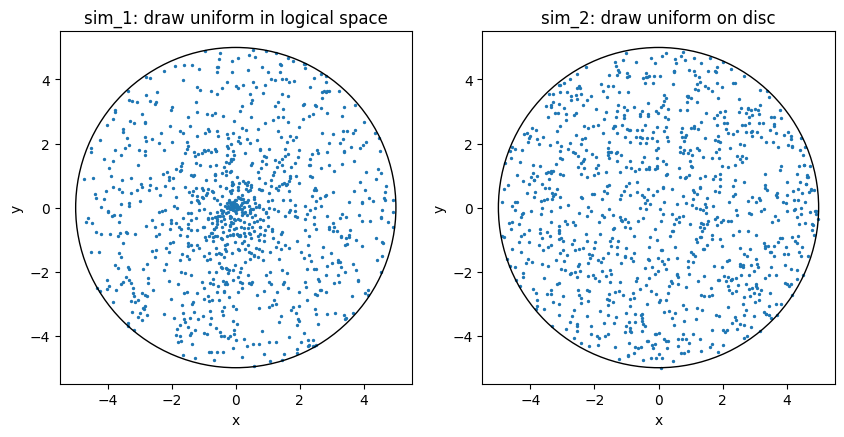

In [16]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(10, 6))

orbits = sim.orbits.kinetic_ions
orbits_uni = sim_2.orbits.kinetic_ions

plt.subplot(1, 2, 1)
plt.scatter(orbits[0, :, 0], orbits[0, :, 1], s=2.0)
circle1 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle1)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_1: draw uniform in logical space")

plt.subplot(1, 2, 2)
plt.scatter(orbits_uni[0, :, 0], orbits_uni[0, :, 1], s=2.0)
circle2 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle2)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_2: draw uniform on disc")

### Optional: quasi-uniform marker loading (Sobol)

For a more homogeneous particle representation with limited particle count, use Sobol-based loading.

Set `loading="sobol_standard"` or `loading="sobol_antithetic"` in `LoadingParameters`:


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 118.81step/s]


Struphy run finished.



Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_3


...

self.orbits:


    kinetic_ions, shape = (2, 1000, 8)
        Number of time points: 2
        Number of particles:   1000
        Number of attributes:  8



self.f:


self.n_sph:


Text(0.5, 1.0, 'sim_3: draw using sobol_standard')

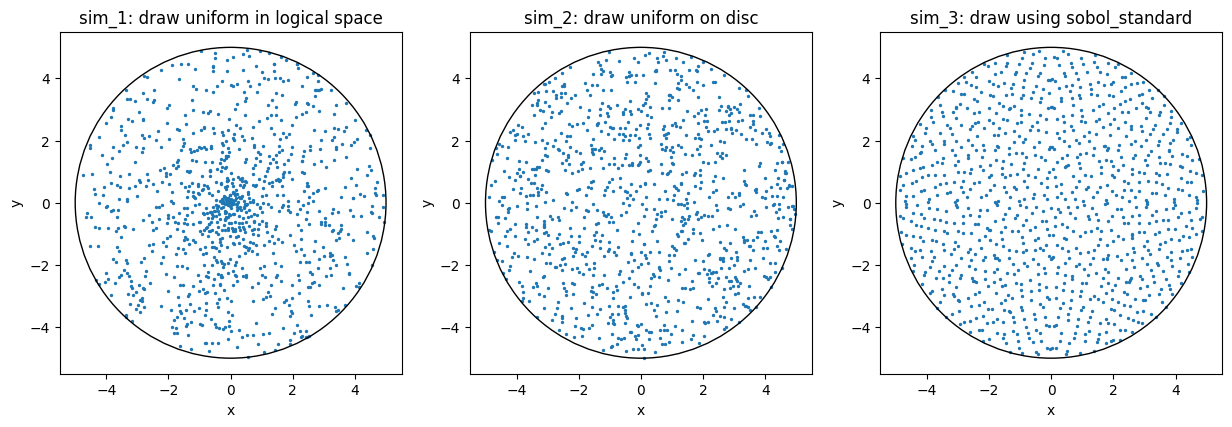

In [17]:
env_3 = EnvironmentOptions(sim_folder="sim_3")
model_3 = Vlasov()
sim_3 = Simulation.spawn_sister(sim, env=env_3, model=model_3)

# species parameters
loading_params_3 = LoadingParameters(Np=1000, spatial="disc", loading="sobol_standard")

model_3.kinetic_ions.set_markers(
    loading_params=loading_params_3, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params,
)

# propagator options
model_3.propagators.push_vxb.options = model_3.propagators.push_vxb.Options()
model_3.propagators.push_eta.options = model_3.propagators.push_eta.Options()

# initial conditions (background + perturbation)
model_3.kinetic_ions.var.add_background(background)

sim_3.run()
sim_3.pproc()
sim_3.load_plotting_data()

fig = plt.figure(figsize=(15, 6))

orbits_standard = sim_3.orbits.kinetic_ions

plt.subplot(1, 3, 1)
plt.scatter(orbits[0, :, 0], orbits[0, :, 1], s=2.0)
circle1 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle1)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_1: draw uniform in logical space")

plt.subplot(1, 3, 2)
plt.scatter(orbits_uni[0, :, 0], orbits_uni[0, :, 1], s=2.0)
circle2 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle2)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_2: draw uniform on disc")

plt.subplot(1, 3, 3)
plt.scatter(orbits_standard[0, :, 0], orbits_standard[0, :, 1], s=2.0)
circle3 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle3)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_3: draw using sobol_standard")

### Optional: antithetic Sobol loading

Repeat the same setup with `loading="sobol_antithetic"` if you want a variance-reduced counterpart to standard Sobol loading:


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/1 [00:00<?, ?step/s]

Time stepping: 100%|██████████| 1/1 [00:00<00:00, 118.02step/s]


Struphy run finished.



Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_3


...

self.orbits:


    kinetic_ions, shape = (2, 1000, 8)
        Number of time points: 2
        Number of particles:   1000
        Number of attributes:  8



self.f:


self.n_sph:


Text(0.5, 1.0, 'sim_3: draw using sobol_standard')

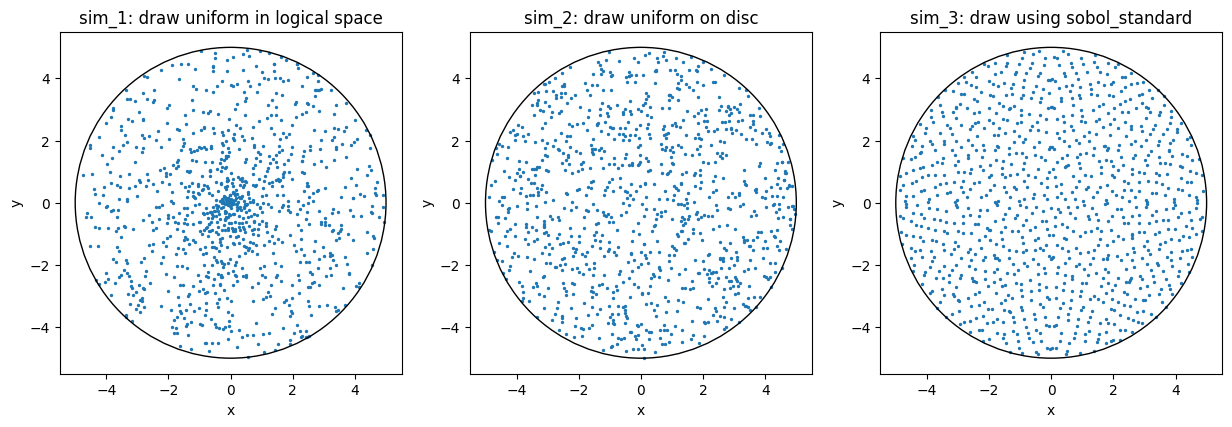

In [18]:
env_3 = EnvironmentOptions(sim_folder="sim_3")
model_3 = Vlasov()
sim_3 = Simulation.spawn_sister(sim, env=env_3, model=model_3)

# species parameters
loading_params_3 = LoadingParameters(Np=1000, spatial="disc", loading="sobol_standard")

model_3.kinetic_ions.set_markers(
    loading_params=loading_params_3, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params,
)

# propagator options
model_3.propagators.push_vxb.options = model_3.propagators.push_vxb.Options()
model_3.propagators.push_eta.options = model_3.propagators.push_eta.Options()

# initial conditions (background + perturbation)
model_3.kinetic_ions.var.add_background(background)

sim_3.run()
sim_3.pproc()
sim_3.load_plotting_data()

fig = plt.figure(figsize=(15, 6))

orbits_standard = sim_3.orbits.kinetic_ions

plt.subplot(1, 3, 1)
plt.scatter(orbits[0, :, 0], orbits[0, :, 1], s=2.0)
circle1 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle1)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_1: draw uniform in logical space")

plt.subplot(1, 3, 2)
plt.scatter(orbits_uni[0, :, 0], orbits_uni[0, :, 1], s=2.0)
circle2 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle2)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_2: draw uniform on disc")

plt.subplot(1, 3, 3)
plt.scatter(orbits_standard[0, :, 0], orbits_standard[0, :, 1], s=2.0)
circle3 = plt.Circle((0, 0), a2, color="k", fill=False)
ax = plt.gca()
ax.add_patch(circle3)
ax.set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("sim_3: draw using sobol_standard")

## Part 2: Reflecting boundary conditions

Next, create a new simulation with 50 time steps and 15 particles in the cylinder.

In addition, enable reflecting boundary conditions in the radial direction. In Struphy this corresponds to logical direction $\eta_1$:

In [19]:
time_opts = Time(dt=0.2, Tend=10.0)
loading_params = LoadingParameters(Np=15, spatial="disc")
boundary_params = BoundaryParameters(bc=("reflect", "periodic", "periodic"))

In [20]:
# light-weight model instance
model = Vlasov()

sim = Simulation(model,
                 env=env,
                 time_opts=time_opts,
                 domain=domain,
                 equil=equil,
                 grid=grid,
                 derham_opts=derham_opts,)

In [21]:
model.kinetic_ions.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params,
)

Set propagator options and initial conditions as in the previous section:

In [22]:
# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

Run the simulation, post-process the output, and plot the resulting trajectories to verify reflections at the radial boundary:

In [23]:
sim.run()


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/50 [00:00<?, ?step/s]

Time stepping:  62%|██████▏   | 31/50 [00:00<00:00, 308.09step/s]

Time stepping: 100%|██████████| 50/50 [00:00<00:00, 303.69step/s]


Struphy run finished.


In [24]:
sim.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 15 marker orbits for kinetic_ions


  0%|          | 0/51 [00:00<?, ?it/s]

100%|██████████| 51/51 [00:00<00:00, 853.83it/s]

In [25]:
sim.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(51,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (51, 15, 8)
        Number of time points: 51
        Number of particles:   15
        Number of attributes:  8



self.f:


self.n_sph:


Under `sim.orbits[<species_name>]`, Struphy stores orbit data in a 3D NumPy array:

- axis 0: time step,
- axis 1: particle index,
- axis 2: particle attributes.

The first three attributes are particle positions, followed by velocities and then weights (initial and time-dependent).

In [26]:
orbits = sim.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]
Nattr = orbits.shape[2]

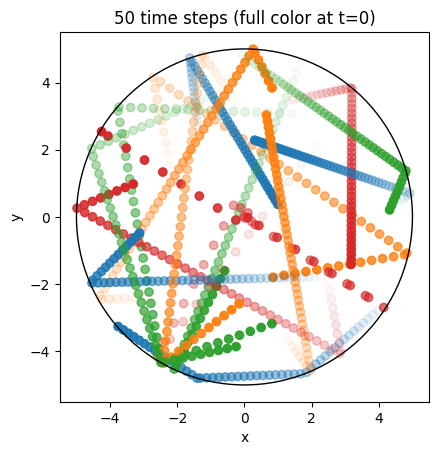

In [27]:
import numpy as np

fig = plt.figure()
ax = fig.gca()

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# create alpha for color scaling
Tend = time_opts.Tend
alpha = np.linspace(1.0, 0.0, Nt + 1)

# loop through particles, plot all time steps
for i in range(Np):
    ax.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], alpha=alpha)

circle1 = plt.Circle((0, 0), a2, color="k", fill=False)

ax.add_patch(circle1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{Nt - 1} time steps (full color at t=0)");

## Part 3: Particles in a cylinder with a magnetic field

Now extend the setup by adding a static magnetic background field.

You do this by assigning an object from the `equils` module:

In [28]:
B0x = 0.0
B0y = 0.0
B0z = 1.0
equil = equils.HomogenSlab(B0x=B0x, B0y=B0y, B0z=B0z)

To evaluate the equilibrium efficiently in particle kernels, project it onto the spline basis. This requires creating a De Rham complex:

In [29]:
bcs = (("free", "free"), None, None)
derham_opts = DerhamOptions(bcs=bcs)

Create a lightweight model instance and configure species options.

Here we choose to `remove` particles that hit the boundary in radial direction $\eta_1$:

In [30]:
# light-weight model instance
model = Vlasov()

sim_withB = sim.spawn_sister(model=model,
                             equil=equil,
                             derham_opts=derham_opts,)

In [31]:
loading_params = LoadingParameters(Np=20)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))

model.kinetic_ions.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params,
)

# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

Run the case, post-process results, load the data, and plot trajectories to see how the magnetic field modifies particle motion:

In [32]:
sim_withB.run()


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/50 [00:00<?, ?step/s]

Time stepping:  64%|██████▍   | 32/50 [00:00<00:00, 319.30step/s]

Time stepping: 100%|██████████| 50/50 [00:00<00:00, 312.83step/s]


Struphy run finished.


In [33]:
sim_withB.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 20 marker orbits for kinetic_ions


  0%|          | 0/51 [00:00<?, ?it/s]

100%|██████████| 51/51 [00:00<00:00, 813.70it/s]

In [34]:
sim_withB.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(51,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (51, 20, 8)
        Number of time points: 51
        Number of particles:   20
        Number of attributes:  8



self.f:


self.n_sph:


In [35]:
orbits = sim_withB.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

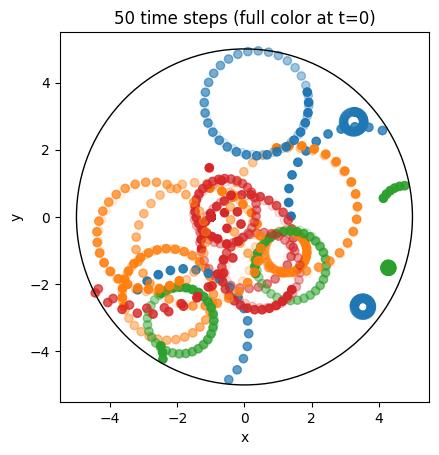

In [36]:
fig = plt.figure()
ax = fig.gca()

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# create alpha for color scaling
Tend = time_opts.Tend
alpha = np.linspace(1.0, 0.0, Nt + 1)

# loop through particles, plot all time steps
for i in range(Np):
    ax.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], alpha=alpha)

circle1 = plt.Circle((0, 0), a2, color="k", fill=False)

ax.add_patch(circle1)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"{int(Nt - 1)} time steps (full color at t=0)");

## Part 4: Particles in a tokamak equilibrium

As a more realistic example, use an ASDEX-Upgrade equilibrium loaded from an EQDSK file.

Instantiate an `EQDSKequilibrium` with mostly default settings and adjust the density:

In [37]:
n1 = 0.0
n2 = 0.0
na = 1.0
equil = equils.EQDSKequilibrium(n1=n1, n2=n2, na=na)

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/struphy/fields_background/equils.py:1780: UserWarning: self.units =<struphy.physics.physics.Units object at 0x7fdd586806a0>, no rescaling performed in EQDSK output.
  warnings.warn(


`EQDSKequilibrium` inherits from `AxisymmMHDequilibrium` and `CartesianMHDequilibrium`, so in principle you could choose different mappings.

For a domain that matches the equilibrium boundary, use the `Tokamak` mapping:

In [38]:
num_elements = (28, 72)
degree = (3, 3)
psi_power = 0.6
psi_shifts = (1e-6, 1.0)
domain = domains.Tokamak(equilibrium=equil, num_elements=num_elements, degree=degree, psi_power=psi_power, psi_shifts=psi_shifts)

The `Tokamak` domain is a `PoloidalSplineTorus`. The coordinate relation between Cartesian $(x,y,z)$ and Tokamak $(R,Z,\phi)$ variables is

$$
 \begin{aligned}
 x &= R \cos(\phi)\,,
 \\
 y &= -R \sin(\phi)\,,
 \\
 z &= Z\,,
 \end{aligned}
$$

where $(R,Z)$ spans the poloidal plane.

Tokamak coordinates are connected to torus coordinates $(r,\theta,\phi)$ through a polar mapping in the poloidal plane:

$$
 \begin{aligned}
 R &= R_0 + r \cos(\theta)\,,
 \\
 Z &= r \sin(\theta)\,,
 \\
 \phi &= \phi\,,
 \end{aligned}
$$

and torus coordinates map to Struphy logical coordinates $\boldsymbol\eta=(\eta_1,\eta_2,\eta_3)\in[0,1]^3$ as

$$
 \begin{aligned}
 r &= a_1 + (a_2-a_1)\eta_1\,,
 \\
 \theta &= 2\pi\eta_2\,,
 \\
 \phi &= 2\pi\eta_3\,,
 \end{aligned}
$$

with $a_2>a_1\geq 0$ the radial bounds.

You can inspect this relation in mappings such as `HollowTorus` (more advanced angle parametrizations $\theta(\eta_1,\eta_2)$ also exist).

As a quick sanity check, plot the magnetic-field magnitude:

1. in the poloidal plane at $\phi=0$,
2. in the top view at $z=0$.

In [39]:
import numpy as np

# logical grid on the unit cube
e1 = np.linspace(0.0, 1.0, 101)
e2 = np.linspace(0.0, 1.0, 101)
e3 = np.linspace(0.0, 1.0, 101)

# move away from the singular point r = 0
e1[0] += 1e-5

In [40]:
# logical coordinates of the poloidal plane at phi = 0
eta_poloidal = (e1, e2, 0.0)
# logical coordinates of the top view at theta = 0
eta_topview_1 = (e1, 0.0, e3)
# logical coordinates of the top view at theta = pi
eta_topview_2 = (e1, 0.5, e3)

In [41]:
# Cartesian coordinates (squeezed)
x_pol, y_pol, z_pol = domain(*eta_poloidal, squeeze_out=True)
x_top1, y_top1, z_top1 = domain(*eta_topview_1, squeeze_out=True)
x_top2, y_top2, z_top2 = domain(*eta_topview_2, squeeze_out=True)

print(f"{x_pol.shape = }")
print(f"{x_top1.shape = }")
print(f"{x_top2.shape = }")

x_pol.shape = (101, 101)
x_top1.shape = (101, 101)
x_top2.shape = (101, 101)


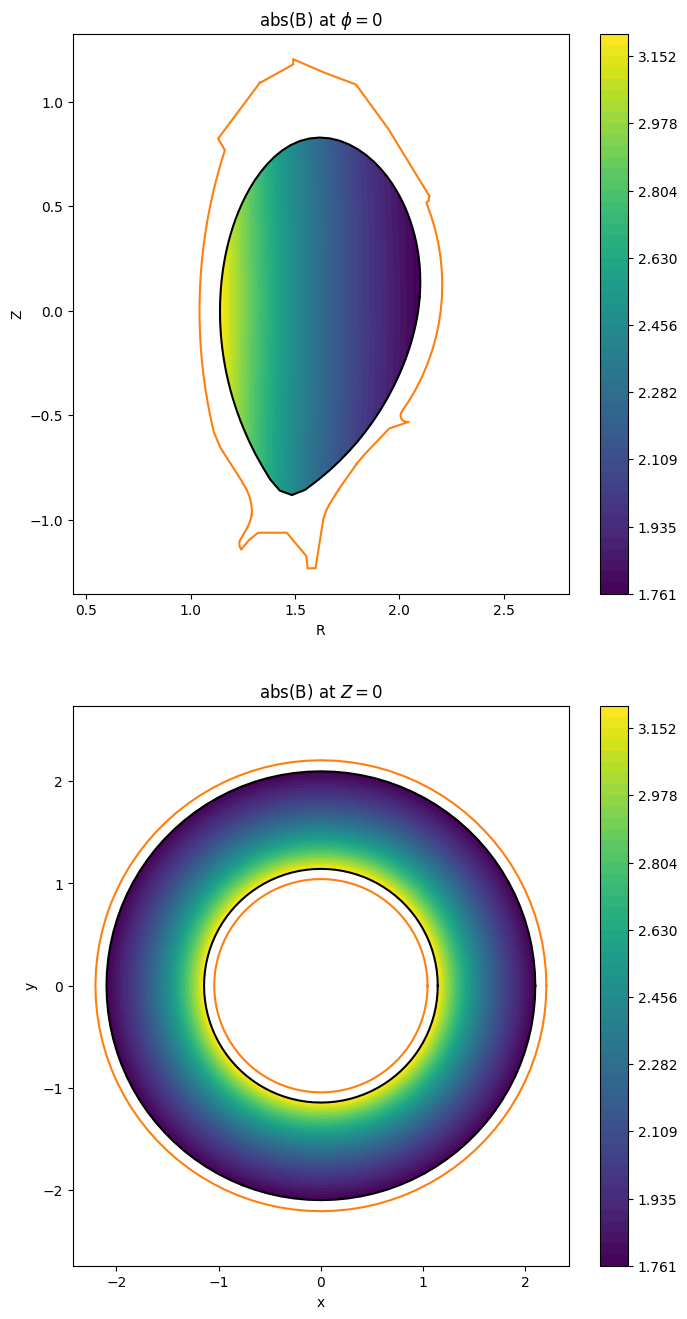

In [42]:
# generate two axes
fig, axs = plt.subplots(2, 1, figsize=(8, 16))
ax = axs[0]
ax_top = axs[1]

# min/max of field strength
equil.domain = domain
Bmax = np.max(equil.absB0(*eta_topview_2, squeeze_out=True))
Bmin = np.min(equil.absB0(*eta_topview_1, squeeze_out=True))
levels = np.linspace(Bmin, Bmax, 51)

# absolute magnetic field at phi = 0
im = ax.contourf(x_pol, z_pol, equil.absB0(*eta_poloidal, squeeze_out=True), levels=levels)

# absolute magnetic field at Z = 0
im_top = ax_top.contourf(x_top1, y_top1, equil.absB0(*eta_topview_1, squeeze_out=True), levels=levels)
ax_top.contourf(x_top2, y_top2, equil.absB0(*eta_topview_2, squeeze_out=True), levels=levels)

# last closed flux surface, poloidal
ax.plot(x_pol[-1], z_pol[-1], color="k")

# last closed flux surface, toroidal
ax_top.plot(x_top1[-1], y_top1[-1], color="k")
ax_top.plot(x_top2[-1], y_top2[-1], color="k")

# limiter, poloidal
ax.plot(equil.limiter_pts_R, equil.limiter_pts_Z, "tab:orange")
ax.axis("equal")
ax.set_xlabel("R")
ax.set_ylabel("Z")
ax.set_title("abs(B) at $\phi=0$")
fig.colorbar(im)
# limiter, toroidal
limiter_Rmax = np.max(equil.limiter_pts_R)
limiter_Rmin = np.min(equil.limiter_pts_R)

thetas = 2 * np.pi * e2
limiter_x_max = limiter_Rmax * np.cos(thetas)
limiter_y_max = -limiter_Rmax * np.sin(thetas)
limiter_x_min = limiter_Rmin * np.cos(thetas)
limiter_y_min = -limiter_Rmin * np.sin(thetas)

ax_top.plot(limiter_x_max, limiter_y_max, "tab:orange")
ax_top.plot(limiter_x_min, limiter_y_min, "tab:orange")
ax_top.axis("equal")
ax_top.set_xlabel("x")
ax_top.set_ylabel("y")
ax_top.set_title("abs(B) at $Z=0$")
fig.colorbar(im_top);

As before, build a De Rham complex so the equilibrium can be projected onto the spline basis:

In [43]:
num_elements = (32, 72, 1)
grid = grids.TensorProductGrid(num_elements=num_elements)

degree = (3, 3, 1)
bcs = (("free", "free"), None, None)
derham_opts = DerhamOptions(degree=degree, bcs=bcs)

For this example we run 15000 time steps using a second-order splitting scheme:

In [44]:
time_opts = Time(dt=0.2, Tend=3000, split_algo="Strang")

Set up a simulation with four hand-picked particle initial conditions to study representative orbit types in this equilibrium:

In [45]:
# light-weight model instance
model = Vlasov()

sim_asdex = Simulation(model,
                       env=env,
                       time_opts=time_opts,
                       domain=domain,
                       equil=equil,
                       grid=grid,
                       derham_opts=derham_opts,)

In [46]:
# initial particle positions in phase space
initial = (
    (0.501, 0.001, 0.001, 0.0, 0.0450, -0.04),  # co-passing particle
    (0.511, 0.001, 0.001, 0.0, -0.0450, -0.04),  # counter passing particle
    (0.521, 0.001, 0.001, 0.0, 0.0105, -0.04),  # co-trapped particle
    (0.531, 0.001, 0.001, 0.0, -0.0155, -0.04),
)

loading_params = LoadingParameters(Np=4, seed=1608, specific_markers=initial)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))

model.kinetic_ions.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params,
    boundary_params=boundary_params, 
    saving_params=saving_params,
    bufsize=2.0
)

# propagator options
model.propagators.push_vxb.options = model.propagators.push_vxb.Options()
model.propagators.push_eta.options = model.propagators.push_eta.Options()

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.Maxwellian3D(n=(1.0, perturbation))

model.kinetic_ions.var.add_background(background)

In [47]:
sim_asdex.run()


Starting run for model Vlasov ...


Time stepping:   0%|          | 0/15000 [00:00<?, ?step/s]

Time stepping:   0%|          | 29/15000 [00:00<00:52, 285.90step/s]

Time stepping:   0%|          | 58/15000 [00:00<00:52, 285.75step/s]

Time stepping:   1%|          | 87/15000 [00:00<00:52, 285.51step/s]

...

Time stepping: 100%|█████████▉| 14925/15000 [00:55<00:00, 280.85step/s]

Time stepping: 100%|█████████▉| 14954/15000 [00:55<00:00, 280.21step/s]

Time stepping: 100%|█████████▉| 14983/15000 [00:55<00:00, 281.39step/s]

Time stepping: 15001step [00:55, 270.89step/s]                         


Struphy run finished.


In [48]:
sim_asdex.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 4 marker orbits for kinetic_ions


  0%|          | 0/15002 [00:00<?, ?it/s]

  1%|          | 87/15002 [00:00<00:17, 869.59it/s]

...

 98%|█████████▊| 14671/15002 [00:17<00:00, 841.05it/s]

 98%|█████████▊| 14756/15002 [00:17<00:00, 839.82it/s]

 99%|█████████▉| 14841/15002 [00:17<00:00, 840.28it/s]

100%|█████████▉| 14927/15002 [00:17<00:00, 845.79it/s]

100%|██████████| 15002/15002 [00:17<00:00, 849.41it/s]

In [49]:
sim_asdex.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(15002,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (15002, 4, 8)
        Number of time points: 15002
        Number of particles:   4
        Number of attributes:  8



self.f:


self.n_sph:


In [50]:
orbits = sim_asdex.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

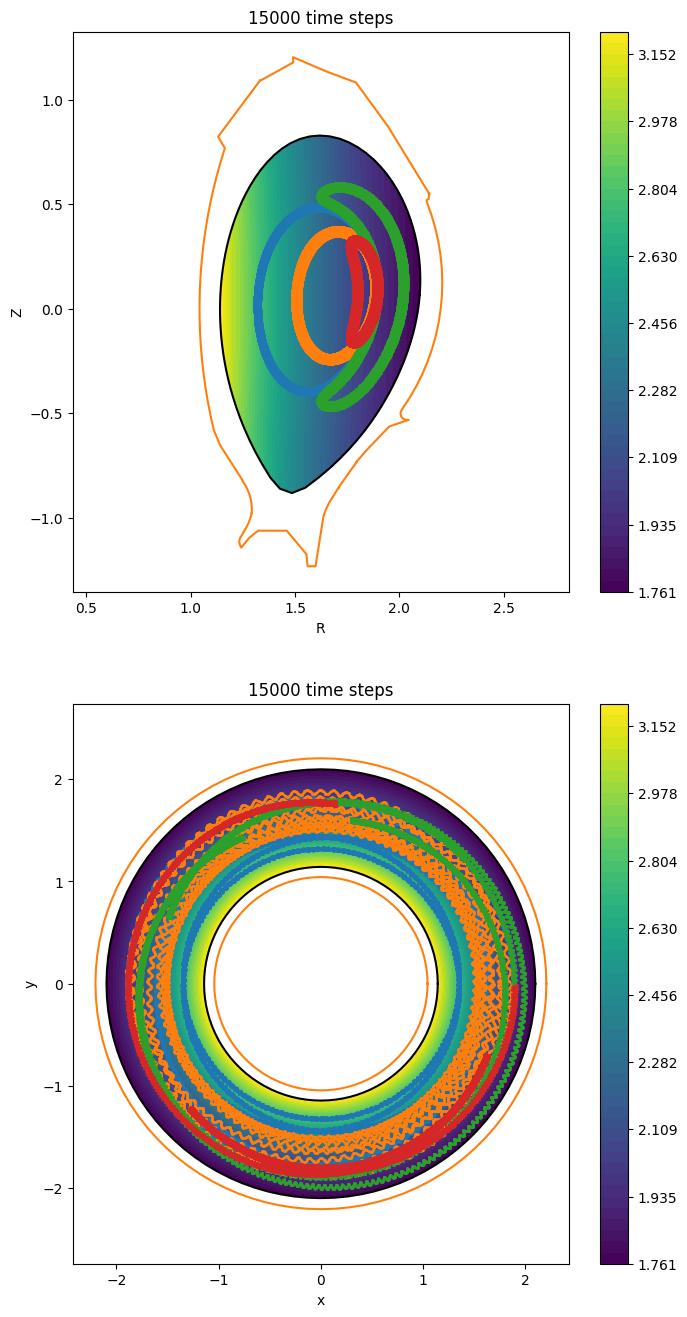

In [51]:
import math

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

dt = time_opts.dt
Tend = time_opts.Tend

for i in range(Np):
    r = np.sqrt(orbits[:, i, 0] ** 2 + orbits[:, i, 1] ** 2)
    # poloidal
    ax.scatter(r, orbits[:, i, 2], c=colors[i % 4], s=1)
    # top view
    ax_top.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], s=1)

ax.set_title(f"{math.ceil(Tend / dt)} time steps")
ax_top.set_title(f"{math.ceil(Tend / dt)} time steps")
fig

## Part 5: Guiding centers in a tokamak equilibrium

Finally, repeat the experiment with the guiding-center model and compare the trajectory behavior to full particle tracing:

In [52]:
from struphy.models import GuidingCenter

# light-weight model instance
model = GuidingCenter()

In [53]:
time_opts = Time(dt=0.1, Tend=100, split_algo="Strang")

sim_gc = sim_asdex.spawn_sister(model=model, time_opts=time_opts)

In [54]:
# initial phase space coordinates
initial = (
    (0.501, 0.001, 0.001, -1.935, 1.72),  # co-passing particle
    (0.501, 0.001, 0.001, 1.935, 1.72),  # couner-passing particle
    (0.501, 0.001, 0.001, -0.6665, 1.72),  # co-trapped particle
    (0.501, 0.001, 0.001, 0.4515, 1.72),
)  # counter-trapped particl

loading_params = LoadingParameters(Np=4, seed=1608, specific_markers=initial)
boundary_params = BoundaryParameters(bc=("remove", "periodic", "periodic"))

model.kinetic_ions.set_markers(
    loading_params=loading_params, 
    weights_params=weights_params, 
    boundary_params=boundary_params,
    saving_params=saving_params,
    bufsize=2.0,
)

# propagator options
model.propagators.push_bxe.options = model.propagators.push_bxe.Options(tol=1e-5)
model.propagators.push_parallel.options = model.propagators.push_parallel.Options(tol=1e-5)

# initial conditions (background + perturbation)
perturbation = None
background = maxwellians.GyroMaxwellian2D(n=(1.0, perturbation), equil=equil)

model.kinetic_ions.var.add_background(background)

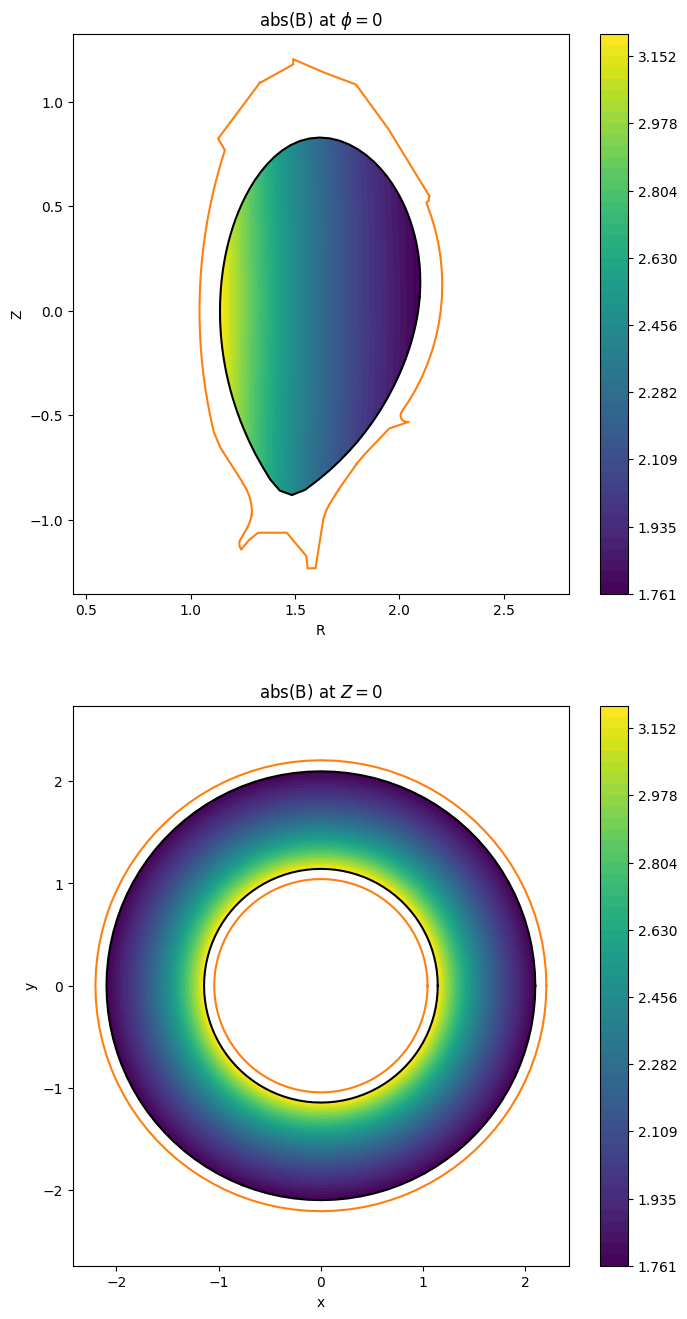

In [55]:
# generate two axes
fig, axs = plt.subplots(2, 1, figsize=(8, 16))
ax = axs[0]
ax_top = axs[1]

# min/max of field strength
equil.domain = domain
Bmax = np.max(equil.absB0(*eta_topview_2, squeeze_out=True))
Bmin = np.min(equil.absB0(*eta_topview_1, squeeze_out=True))
levels = np.linspace(Bmin, Bmax, 51)

# absolute magnetic field at phi = 0
im = ax.contourf(x_pol, z_pol, equil.absB0(*eta_poloidal, squeeze_out=True), levels=levels)

# absolute magnetic field at Z = 0
im_top = ax_top.contourf(x_top1, y_top1, equil.absB0(*eta_topview_1, squeeze_out=True), levels=levels)
ax_top.contourf(x_top2, y_top2, equil.absB0(*eta_topview_2, squeeze_out=True), levels=levels)

# last closed flux surface, poloidal
ax.plot(x_pol[-1], z_pol[-1], color="k")

# last closed flux surface, toroidal
ax_top.plot(x_top1[-1], y_top1[-1], color="k")
ax_top.plot(x_top2[-1], y_top2[-1], color="k")

# limiter, poloidal
ax.plot(equil.limiter_pts_R, equil.limiter_pts_Z, "tab:orange")
ax.axis("equal")
ax.set_xlabel("R")
ax.set_ylabel("Z")
ax.set_title("abs(B) at $\phi=0$")
fig.colorbar(im)
# limiter, toroidal
limiter_Rmax = np.max(equil.limiter_pts_R)
limiter_Rmin = np.min(equil.limiter_pts_R)

thetas = 2 * np.pi * e2
limiter_x_max = limiter_Rmax * np.cos(thetas)
limiter_y_max = -limiter_Rmax * np.sin(thetas)
limiter_x_min = limiter_Rmin * np.cos(thetas)
limiter_y_min = -limiter_Rmin * np.sin(thetas)

ax_top.plot(limiter_x_max, limiter_y_max, "tab:orange")
ax_top.plot(limiter_x_min, limiter_y_min, "tab:orange")
ax_top.axis("equal")
ax_top.set_xlabel("x")
ax_top.set_ylabel("y")
ax_top.set_title("abs(B) at $Z=0$")
fig.colorbar(im_top);

In [56]:
sim_gc.run()


Starting run for model GuidingCenter ...


Time stepping:   0%|          | 0/1000 [00:00<?, ?step/s]

Time stepping:   2%|▏         | 21/1000 [00:00<00:04, 204.38step/s]

Time stepping:   4%|▍         | 42/1000 [00:00<00:04, 207.35step/s]

Time stepping:   6%|▋         | 63/1000 [00:00<00:04, 208.55step/s]

...

Time stepping:  95%|█████████▌| 952/1000 [00:04<00:00, 204.75step/s]

Time stepping:  97%|█████████▋| 973/1000 [00:04<00:00, 205.85step/s]

Time stepping:  99%|█████████▉| 994/1000 [00:04<00:00, 205.83step/s]

Time stepping: 1001step [00:04, 204.94step/s]                       


Struphy run finished.


In [57]:
sim_gc.pproc()


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 4 marker orbits for kinetic_ions


  0%|          | 0/1002 [00:00<?, ?it/s]

  9%|▉         | 88/1002 [00:00<00:01, 879.95it/s]

...

 70%|██████▉   | 700/1002 [00:00<00:00, 872.26it/s]

 79%|███████▊  | 789/1002 [00:00<00:00, 875.97it/s]

 88%|████████▊ | 878/1002 [00:01<00:00, 877.39it/s]

 97%|█████████▋| 967/1002 [00:01<00:00, 878.09it/s]

100%|██████████| 1002/1002 [00:01<00:00, 870.27it/s]

In [58]:
sim_gc.load_plotting_data()


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_1/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(1002,)



self.spline_values:


self.orbits:


    kinetic_ions, shape = (1002, 4, 8)
        Number of time points: 1002
        Number of particles:   4
        Number of attributes:  8



self.f:


self.n_sph:


In [59]:
orbits = sim_gc.orbits.kinetic_ions

Nt = orbits.shape[0]
Np = orbits.shape[1]

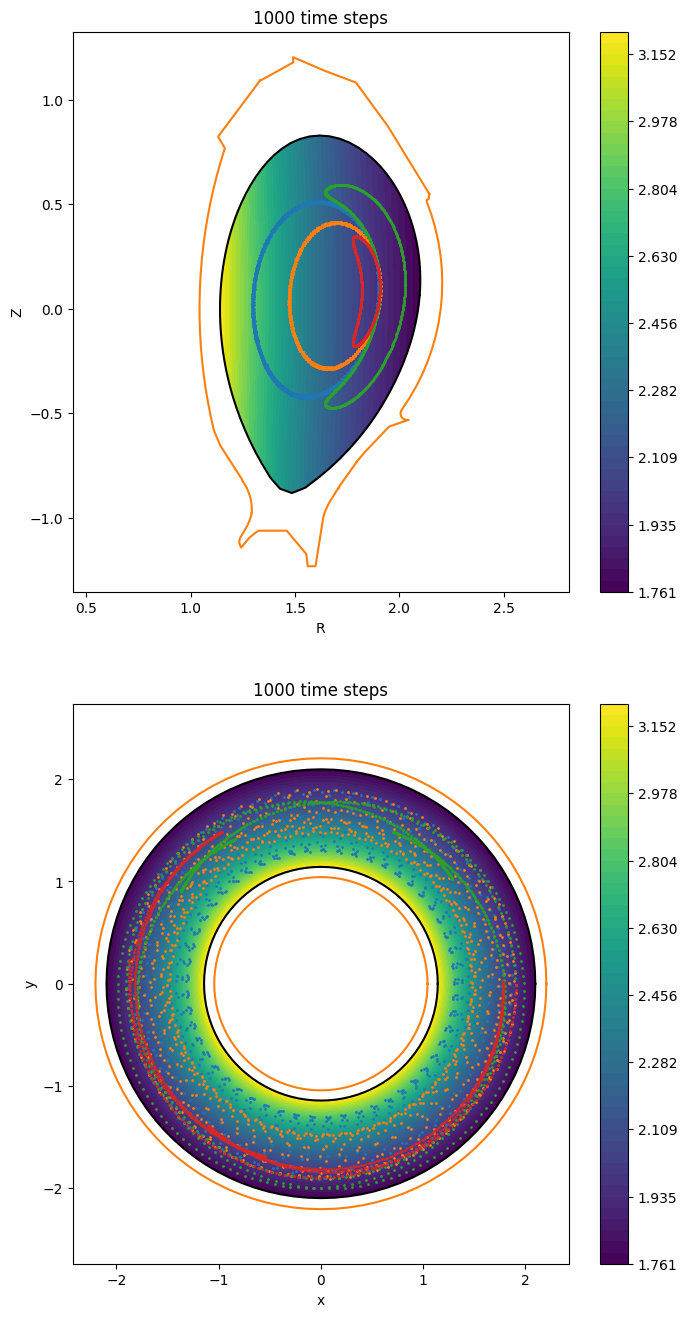

In [60]:
import math

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

dt = time_opts.dt
Tend = time_opts.Tend

for i in range(Np):
    r = np.sqrt(orbits[:, i, 0] ** 2 + orbits[:, i, 1] ** 2)
    # poloidal
    ax.scatter(r, orbits[:, i, 2], c=colors[i % 4], s=1)
    # top view
    ax_top.scatter(orbits[:, i, 0], orbits[:, i, 1], c=colors[i % 4], s=1)

ax.set_title(f"{math.ceil(Tend / dt)} time steps")
ax_top.set_title(f"{math.ceil(Tend / dt)} time steps")
fig